In [ ]:
# -----------------------------------------------------------------------------
# Imports and global configuration
# -----------------------------------------------------------------------------
import pandas as pd
import torch, torchvision, torchaudio
import torch.nn as nn 
import numpy as np

from sklearn import model_selection, preprocessing
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
from sklearn.metrics import mean_squared_error, mean_absolute_error

import matplotlib.pyplot as plt
from IPython.display import clear_output

# Enable CuDNN auto-tuner to select the fastest convolution algorithms
# for the current configuration. This can improve runtime on GPU.
torch.backends.cudnn.benchmark = True

# Progress bars for training/evaluation loops
from tqdm.auto import tqdm # to show the progress

# -----------------------------------------------------------------------------
# Hyperparameters and runtime setup
# -----------------------------------------------------------------------------
NUM_EMBEDDINGS = 32   # dimensionality of user/movie embedding vectors
BATCH_SIZE = 4        # number of samples per gradient update (kept small for stability/testing)
NUM_EPOCHS = 2        # number of full passes over the training data

# Select the best available device (GPU if present, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Quick sanity print to confirm CUDA availability and the detected GPU model
print("CUDA disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

### Recommender Systems 

In [ ]:
# -----------------------------------------------------------------------------
# Recommender Systems — Step 1: load ratings data
# I load the MovieLens ratings file into a pandas DataFrame. This table
# (userId, movieId, rating, timestamp) is the core input for the pipeline.
# Note: the 32M-rows CSV is large; loading can take time and ~1 GB of RAM.
# The relative path 'ml-32m/ratings.csv' must be valid from this notebook.
# -----------------------------------------------------------------------------

# --- Load ratings ---
df = pd.read_csv('ml-32m/ratings.csv')


In [ ]:
# -----------------------------------------------------------------------------
# Quick peek at the loaded data
# I display the first two rows to confirm the expected columns and spot
# any obvious parsing issues (types, missing columns, etc.).
# -----------------------------------------------------------------------------
df.head(2)

In [ ]:
# -----------------------------------------------------------------------------
# Basic dataset statistics
# I compute the number of distinct users and movies to gauge the shape of the
# implicit user–item matrix (rows ≈ users, columns ≈ movies). This helps size
# the embedding tables later on and sanity-checks the dataset.
# -----------------------------------------------------------------------------
print(f"Unique users: {df.userId.nunique()}, "
      f"Unique movies: {df.movieId.nunique()}")

In [30]:
# -----------------------------------------------------------------------------
# Data container for (user, movie, rating) triplets
# -----------------------------------------------------------------------------
# I wrap the raw columns into a PyTorch Dataset so that later I can plug it
# into a DataLoader (for batching, shuffling, and parallel loading). This keeps
# data handling modular and consistent with the training loop.
#
# Note: I return tensors directly in __getitem__, so downstream code can move
# them to GPU without extra casting. Ratings are returned as torch.long here;
# for regression I will cast them to float in the training loop.
# -----------------------------------------------------------------------------
class MovieDataset(Dataset):
    def __init__(self, users, movies, ratings) -> None:
        """
        Custom PyTorch Dataset for user–movie–rating triplets.

        Parameters
        ----------
        users : array-like
            Sequence of user identifiers (indexable).
        movies : array-like
            Sequence of movie identifiers (aligned with `users`).
        ratings : array-like
            Sequence of observed ratings (aligned with `users` and `movies`).
        """
        super().__init__()
        self.users = users
        self.movies = movies
        self.ratings = ratings

    def __len__(self):
        """
        Returns
        -------
        int
            Total number of samples (i.e., number of ratings).
        """
        return len(self.users)

    def __getitem__(self, idx):
        """
        Retrieve a single (user, movie, rating) sample by index.

        Parameters
        ----------
        idx : int
            Position of the sample to retrieve.

        Returns
        -------
        tuple of torch.Tensor
            (user_id, movie_id, rating) as PyTorch tensors.
            - user_id  : torch.long
            - movie_id : torch.long
            - rating   : torch.long  (cast to float later during training)
        """
        users = self.users[idx]
        movies = self.movies[idx]
        ratings = self.ratings[idx]

        return (
            torch.tensor(users, dtype=torch.long),
            torch.tensor(movies, dtype=torch.long),
            torch.tensor(ratings, dtype=torch.long),
        )

In [ ]:
# -----------------------------------------------------------------------------
# Overview: Embeddings & Rating Prediction (Recommender Context)
# -----------------------------------------------------------------------------
# In this model, each user ID and each movie ID is mapped to a learned dense
# vector (an embedding). These embeddings act as compact feature representations:
# - User embedding ≈ learned profile of user preferences
# - Movie embedding ≈ learned profile of movie characteristics
#
# During training, embeddings start random and are updated via backpropagation
# so that users with similar tastes and movies with similar audiences end up
# with similar vectors. To predict a rating for (user, movie), the pipeline:
#   1) looks up the user embedding and the movie embedding,
#   2) combines them (here, by concatenation),
#   3) passes the combined vector through a linear layer to produce a single
#      scalar: the predicted rating.
#
# Notes:
# - Embedding layers expect integer indices in [0, n-1] for lookups.
# - Concatenation models user/movie information additively; interactions are
#   captured by the downstream linear layer’s weights over the joint vector.
# -----------------------------------------------------------------------------

# --- Model Class ---
class RecommenderSystemsModel(nn.Module):
    def __init__(self, n_users, n_movies, n_embeddings = NUM_EMBEDDINGS):
        """
        Neural recommender with separate embedding tables for users and movies.
        
        Parameters
        ----------
        n_users : int
            Number of distinct users (size of the user ID vocabulary).
        n_movies : int
            Number of distinct movies (size of the movie ID vocabulary).
        n_embeddings : int, optional (default=32)
            Dimensionality of the embedding vectors for users and movies.
        """
        super().__init__()
        # Learnable table mapping each user ID -> embedding vector (size n_embeddings).
        # Each row i stores the embedding for user i; updated during training.
        self.user_embed = nn.Embedding(n_users, n_embeddings)
        # Learnable table mapping each movie ID -> embedding vector (size n_embeddings).
        # Each row j stores the embedding for movie j; updated during training.
        self.movie_embed = nn.Embedding(n_movies, n_embeddings)
        # Linear projection from concatenated [user_emb ; movie_emb] to a single rating.
        # Input dim = 2 * n_embeddings, output dim = 1 (scalar rating).
        self.out = nn.Linear(n_embeddings * 2, 1)

    def forward(self, users, movies):
        """
        Compute predicted ratings for a batch of (user, movie) pairs.

        Parameters
        ----------
        users : torch.LongTensor
            Tensor of user IDs (indices into the user embedding table).
        movies : torch.LongTensor
            Tensor of movie IDs (indices into the movie embedding table).

        Returns
        -------
        torch.Tensor
            Predicted ratings with shape (batch_size, 1).
        """
        # Look up embeddings for users and movies.
        # Shapes: user_embeds = (B, n_embeddings), movie_embeds = (B, n_embeddings)
        user_embeds = self.user_embed(users)
        movie_embeds = self.movie_embed(movies)
        # Concatenate embeddings along feature dimension to form a joint representation.
        # Shape after concat: x = (B, 2 * n_embeddings)
        x = torch.cat([user_embeds, movie_embeds], dim=1)
        # Map the joint representation to a single scalar rating prediction.
        # Shape after linear layer: (B, 1)
        x = self.out(x)
        return x

In [ ]:
# -------------------------------------------------------------------------
# Model training and evaluation setup
# -------------------------------------------------------------------------
# Before training, I need user and movie identifiers mapped to contiguous
# integer indices starting at 0. Embedding layers perform table lookups,
# so valid indices must lie in [0, N-1], where N is the number of distinct
# users (or movies). Using a 0-based, dense index space also avoids wasting
# rows in the embedding tables and guarantees alignment with LabelEncoder’s
# learned vocabulary (classes_).
# -------------------------------------------------------------------------

# Encode user and movie IDs so they start at 0 and are contiguous.
lbl_user = preprocessing.LabelEncoder()
lbl_movie = preprocessing.LabelEncoder()

# Transform raw IDs into 0-based integer indices.
df['userId']  = lbl_user.fit_transform(df['userId'].values)
df['movieId'] = lbl_movie.fit_transform(df['movieId'].values)

In [ ]:
# -------------------------------------------------------------------------
# Train–test split
# -------------------------------------------------------------------------
# To evaluate the recommender system properly, we divide the dataset into
# a training set and a test set:
#   - Training set (80% of the data): used to fit the model parameters.
#   - Test set (20% of the data): held out and used only for evaluation,
#     ensuring that performance is measured on unseen examples.
#
# The parameter `random_state=123` fixes the random seed, so that the
# split is reproducible (same train/test partition every run).
# -------------------------------------------------------------------------

df_train, df_test = model_selection.train_test_split(
    df,
    test_size=0.2,
    random_state=123
)

In [ ]:
# -------------------------------------------------------------------------
# Dataset instances for training and validation
# -------------------------------------------------------------------------
# I now wrap the train/test partitions into MovieDataset objects. Each dataset
# exposes:
#   - __len__      → total number of (user, movie, rating) records
#   - __getitem__  → a single triplet returned as PyTorch tensors
#
# Notes:
# - Using `.values` yields NumPy arrays that MovieDataset can index quickly.
# - The three arrays must be aligned row-wise (same ordering and length), which
#   is guaranteed here because they come from the same DataFrame slices.
# - MovieDataset returns `userId` and `movieId` as `torch.long` (for embedding
#   lookups) and `rating` as `torch.long`; I cast ratings to float later in the
#   training loop before computing the regression loss.
# -------------------------------------------------------------------------

train_dataset = MovieDataset(
    users   = df_train.userId.values,
    movies  = df_train.movieId.values,
    ratings = df_train.rating.values
)

valid_dataset = MovieDataset(
    users   = df_test.userId.values,
    movies  = df_test.movieId.values,
    ratings = df_test.rating.values
)

In [ ]:
# -----------------------------------------------------------------------------
# Data loaders
# -----------------------------------------------------------------------------
# I wrap each Dataset with a DataLoader to handle:
#   - batching (controlled by BATCH_SIZE),
#   - shuffling (randomizing sample order per epoch),
#   - and the iteration protocol used in training loops.
# Note: I keep default num_workers=0 here; increasing it can speed up loading
# if the I/O pipeline becomes a bottleneck.
# -----------------------------------------------------------------------------

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True        # shuffle during training to reduce order bias
)

test_loader = DataLoader(
    dataset=valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [ ]:
# -----------------------------------------------------------------------------
# Training loop with per-epoch progress bar and live plotting of train loss
# -----------------------------------------------------------------------------
# I iterate over NUM_EPOCHS. For each epoch, I accumulate the mean training
# loss to monitor optimization. The tqdm progress bar shows batch-level
# progress and the running average of the loss within the epoch.
# After each epoch, I append the average loss to `train_losses` and refresh
# a simple line plot so I can visually track convergence over epochs.
# -----------------------------------------------------------------------------

train_losses = []

model.train()
for epoch_i in range(NUM_EPOCHS):
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch_i+1}/{NUM_EPOCHS}")
    for step, (users, movies, ratings) in enumerate(pbar, start=1):
        # Move batch tensors to the selected device (GPU if available, else CPU)
        users  = users.to(device)
        movies = movies.to(device)
        # Ratings are a regression target; ensure float dtype and shape (B, 1)
        y_true = ratings.to(device).float().unsqueeze(1)

        # Standard training step: clear stale grads → forward → loss → backward → step
        optimizer.zero_grad()
        y_pred = model(users, movies)
        loss = criterion(y_pred, y_true)
        loss.backward()
        optimizer.step()

        # Track running mean loss for this epoch and update the progress bar
        running_loss += loss.item()
        pbar.set_postfix(train_loss=f"{running_loss/step:.4f}")

    # Store the per-epoch average loss for later visualization/analysis
    train_losses.append(running_loss/step)

    # Live update of the training loss curve (one point per epoch)
    clear_output(wait=True)
    plt.figure()
    plt.plot(range(1, len(train_losses)+1), train_losses, label="train")
    plt.xlabel("Epoch"); plt.ylabel("MSE loss"); plt.title("Training Loss")
    plt.legend(); plt.tight_layout(); plt.show()


In [ ]:
# -----------------------------------------------------------------------------
# Evaluation on the held-out test set
# -----------------------------------------------------------------------------
# I switch the model to evaluation mode to disable training-specific layers
# (e.g., dropout/batchnorm behavior) and wrap inference in torch.no_grad()
# to avoid tracking gradients. I collect predictions and ground-truth ratings,
# then compute standard regression metrics: MSE, RMSE, and MAE.
# Notes:
# - I move only inputs needed for the forward pass (users, movies) to the device.
# - I bring predictions back to CPU and convert to Python lists for sklearn.
# - Targets (ratings) come from the DataLoader on CPU; I also convert them to lists.
# - For a fair evaluation, the test_loader should typically have shuffle=False.
# -----------------------------------------------------------------------------

model.eval()
y_preds, y_trues = [], []

with torch.no_grad():
    for users, movies, ratings in test_loader:   # test_loader con shuffle=False
        users  = users.to(device)
        movies = movies.to(device)

        # Forward pass on device; then move predictions to CPU and flatten to 1D list.
        preds = model(users, movies).squeeze(1).cpu().tolist()
        y_preds.extend(preds)

        # Ground-truth ratings: keep on CPU and convert to a flat Python list.
        y_trues.extend(ratings.cpu().tolist())

# Mean Squared Error (average squared difference), Root MSE (in rating units),
# and Mean Absolute Error (average absolute difference). Lower is better.
mse  = mean_squared_error(y_trues, y_preds)
rmse = mse ** 0.5
mae  = mean_absolute_error(y_trues, y_preds)
print(f"MSE: {mse:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")

In [ ]:
# -----------------------------------------------------------------------------
# Collect per-user predictions on the test set
# -----------------------------------------------------------------------------
# I build a dictionary mapping each user_id to a list of (pred_rating, true_rating)
# pairs observed in the test_loader. This structure will be used later to compute
# ranking-style metrics (e.g., Precision@K, Recall@K) by sorting items per user
# according to the predicted score.
# -----------------------------------------------------------------------------

# user_id -> [(pred_rating, true_rating), ...]
user_movies_test = defaultdict(list)

model.eval()
with torch.no_grad():
    for users, movies, ratings in test_loader:   # test_loader with shuffle=False is preferred
        users  = users.to(device)
        movies = movies.to(device)

        # Forward pass: predicted ratings for the batch; shape (B,)
        y_pred = model(users, movies).squeeze(1)  # (B,)

        # Iterate over the batch and populate the per-user list
        for i in range(len(users)):
            uid = int(users[i].item())                 # user id (already label-encoded)
            mid = int(movies[i].item())                # movie id (already label-encoded)
            pred_rating = float(y_pred[i].item())      # model prediction for (uid, mid)
            true_rating = float(ratings[i].item())     # ground-truth rating from the test set
            user_movies_test[uid].append((pred_rating, true_rating))

In [ ]:
# -----------------------------------------------------------------------------
# Precision@K and Recall@K over the test users
# -----------------------------------------------------------------------------
# I compute binary relevance metrics by:
#   1) Defining a relevance threshold (thres): rating >= thres → relevant.
#   2) Sorting each user's test items by the predicted rating (desc).
#   3) Taking the top-K items per user as the recommendation list.
#   4) Counting how many of those top-K are actually relevant (per ground truth).
#
# I report both:
#   - Macro average: simple average across users (each user weights equally).
#   - Micro average: aggregate counts across all users (users with more items weigh more).
#
# Note: This evaluates recommendations only among items that appear for the user
# in the test set (observed interactions), not among all catalog items.
# -----------------------------------------------------------------------------

precision = {}  # per-user precision@K
recall = {}     # per-user recall@K

k = 10
thres = 3.5  # item is relevant if true rating >= thres

# Accumulators for micro-averages
sum_rel_and_rec_k = 0   # relevant AND recommended within top-K
sum_n_rec_k = 0         # total recommended within top-K
sum_n_rel = 0           # total relevant in the user's test set

for uid, user_ratings in user_movies_test.items():
    # Sort user's test items by predicted rating (descending)
    user_ratings.sort(key=lambda x: x[0], reverse=True)

    # Count relevant items across the full user test list (ground truth)
    n_rel = sum((rt >= thres) for (_, rt) in user_ratings)

    # Take top-K by prediction
    topk = user_ratings[:k]

    # Count how many in top-K were predicted as relevant
    n_rec_k = sum((rp >= thres) for (rp, _) in topk)

    # Count items that are both relevant (true) and recommended as relevant (pred) within top-K
    rel_and_rec_k = sum(((rt >= thres) and (rp >= thres)) for (rp, rt) in topk)

    # Per-user metrics (guard against division by zero)
    precision[uid] = rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0.0
    recall[uid]    = rel_and_rec_k / n_rel   if n_rel   != 0 else 0.0

    # Accumulate for micro-averages
    sum_rel_and_rec_k += rel_and_rec_k
    sum_n_rec_k += n_rec_k
    sum_n_rel += n_rel

# --- Averages ---
# Macro-average: average of per-user scores (each user has equal weight)
precision_macro = float(np.mean(list(precision.values()))) if precision else 0.0

# For recall macro, some workflows exclude users with n_rel=0; here I keep the average as-is.
recall_macro = float(np.mean(list(recall.values()))) if recall else 0.0

# Micro-average: global ratios from summed counts (users with more items weigh more)
precision_micro = (sum_rel_and_rec_k / sum_n_rec_k) if sum_n_rec_k > 0 else 0.0
recall_micro    = (sum_rel_and_rec_k / sum_n_rel)   if sum_n_rel   > 0 else 0.0

print(f"Precision@{k} macro: {precision_macro:.4f} | micro: {precision_micro:.4f}")
print(f"Recall@{k}    macro: {recall_macro:.4f}    | micro: {recall_micro:.4f}")

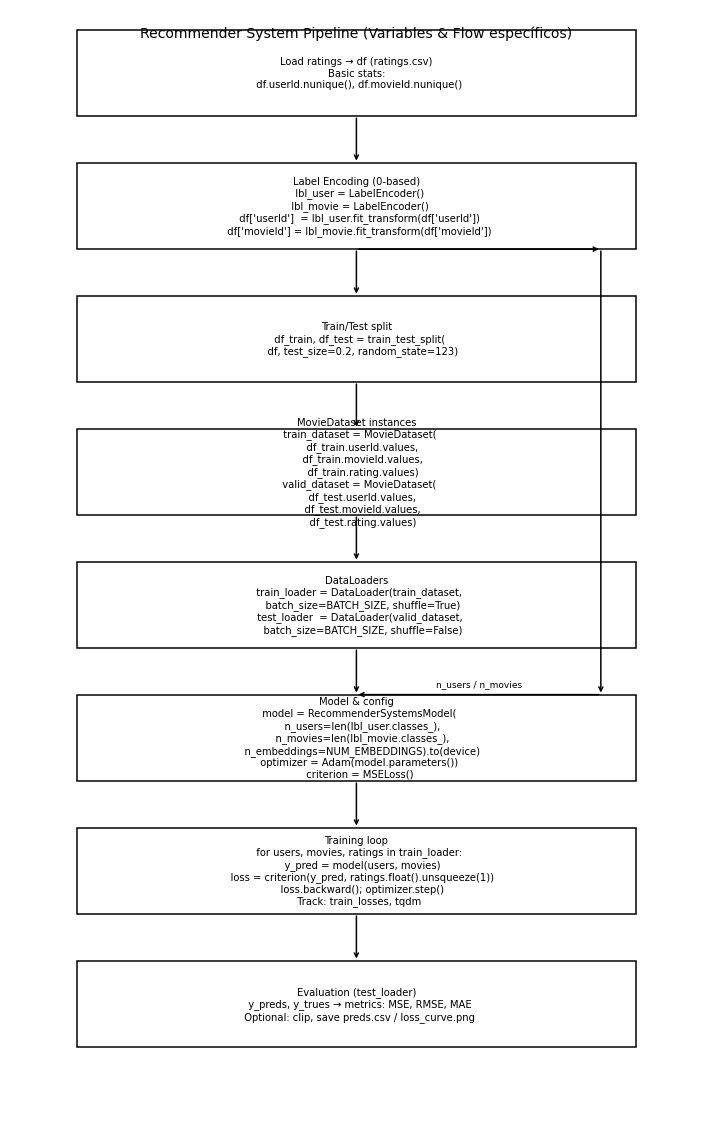

Diagrama saved in: runs\pipeline_diagram_vertical_20250927-194047.png


In [36]:
# -----------------------------------------------------------------------------
# This diagram visualizes the full program flow of my recommender pipeline:
# from loading the ratings, through preprocessing (label encoding and split),
# dataset/dataloader construction, model/optimizer setup, training, and finally
# evaluation. Each box is a pipeline stage; arrows indicate the flow of data
# and how earlier steps feed into later ones (e.g., encoders → model vocab sizes).
# -----------------------------------------------------------------------------

# %matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path
import time

# ------------------ helpers ------------------
# add_box: draws a labeled rectangle centered at (x, y). I keep styling minimal
# so the diagram remains legible in notebooks and exported PNGs.
def add_box(ax, center, text, width=8.0, height=2.6, fs=10):
    x, y = center
    x -= width/2
    y -= height/2
    rect = Rectangle((x, y), width, height, fill=False, linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + width/2, y + height/2, text, ha='center', va='center', fontsize=fs, wrap=True)
    return rect

# connect: draws an arrow from p_from to p_to. Optionally places a label
# near the midpoint (offset by dy) to clarify what flows along the edge.
def connect(ax, p_from, p_to, label=None, dy=0.0):
    ax.annotate("", xy=p_to, xytext=p_from, arrowprops=dict(arrowstyle="->", lw=1.5))
    if label:
        xm, ym = (p_from[0] + p_to[0]) / 2, (p_from[1] + p_to[1]) / 2 + dy
        ax.text(xm, ym, label, ha='center', va='bottom', fontsize=9)

# ------------------ layout (vertical, sin cruces) ------------------
# I use a tall canvas and a single X column so boxes stack vertically.
# This avoids crossing arrows and overcrowded labels.
fig, ax = plt.subplots(figsize=(10, 16))  # más alto que ancho
ax.set_xlim(0, 10)
ax.set_ylim(0, 34)
ax.axis('off')

# posiciones (x fijo para flujo vertical)
# X is the central column; Y contains the vertical positions from top to bottom.
X = 5.0
Y = [32, 28, 24, 20, 16, 12, 8, 4]  # de arriba a abajo

# ------------------ cajas ------------------
# Each box corresponds to a concrete step in my notebook with the exact
# variable names I use, so the diagram matches the code one-to-one.

b0 = add_box(ax, (X, Y[0]),
             "Load ratings → df (ratings.csv)\n"
             "Basic stats:\n"
             "  df.userId.nunique(), df.movieId.nunique()")

b1 = add_box(ax, (X, Y[1]),
             "Label Encoding (0-based)\n"
             "  lbl_user = LabelEncoder()\n"
             "  lbl_movie = LabelEncoder()\n"
             "  df['userId']  = lbl_user.fit_transform(df['userId'])\n"
             "  df['movieId'] = lbl_movie.fit_transform(df['movieId'])")

b2 = add_box(ax, (X, Y[2]),
             "Train/Test split\n"
             "  df_train, df_test = train_test_split(\n"
             "    df, test_size=0.2, random_state=123)")

b3 = add_box(ax, (X, Y[3]),
             "MovieDataset instances\n"
             "  train_dataset = MovieDataset(\n"
             "    df_train.userId.values,\n"
             "    df_train.movieId.values,\n"
             "    df_train.rating.values)\n"
             "  valid_dataset = MovieDataset(\n"
             "    df_test.userId.values,\n"
             "    df_test.movieId.values,\n"
             "    df_test.rating.values)")

b4 = add_box(ax, (X, Y[4]),
             "DataLoaders\n"
             "  train_loader = DataLoader(train_dataset,\n"
             "    batch_size=BATCH_SIZE, shuffle=True)\n"
             "  test_loader  = DataLoader(valid_dataset,\n"
             "    batch_size=BATCH_SIZE, shuffle=False)")

b5 = add_box(ax, (X, Y[5]),
             "Model & config\n"
             "  model = RecommenderSystemsModel(\n"
             "    n_users=len(lbl_user.classes_),\n"
             "    n_movies=len(lbl_movie.classes_),\n"
             "    n_embeddings=NUM_EMBEDDINGS).to(device)\n"
             "  optimizer = Adam(model.parameters())\n"
             "  criterion = MSELoss()")

b6 = add_box(ax, (X, Y[6]),
             "Training loop\n"
             "  for users, movies, ratings in train_loader:\n"
             "    y_pred = model(users, movies)\n"
             "    loss = criterion(y_pred, ratings.float().unsqueeze(1))\n"
             "    loss.backward(); optimizer.step()\n"
             "  Track: train_losses, tqdm")

b7 = add_box(ax, (X, Y[7]),
             "Evaluation (test_loader)\n"
             "  y_preds, y_trues → metrics: MSE, RMSE, MAE\n"
             "  Optional: clip, save preds.csv / loss_curve.png")

# ------------------ conexiones (rectas, de arriba a abajo) ------------------
# Main vertical flow: each stage feeds directly into the next.
for i in range(len(Y) - 1):
    connect(ax, (X, Y[i] - 1.3), (X, Y[i+1] + 1.3))

# flecha extra: vocab sizes de los encoders → modelo
# This side arrow clarifies that lbl_user/classes_ and lbl_movie/classes_
# define the vocabulary sizes used when constructing the embedding tables.
connect(ax, (X+3.5, Y[1]-1.3), (X+3.5, Y[5]+1.3))  # columna lateral derecha
connect(ax, (X,     Y[1]-1.3), (X+3.5, Y[1]-1.3))  # codo
connect(ax, (X+3.5, Y[5]+1.3), (X,     Y[5]+1.3), label="n_users / n_movies", dy=0.2)

# título
ax.text(X, 33.2, "Recommender System Pipeline (Variables & Flow específicos)",
        ha='center', va='center', fontsize=14)

plt.tight_layout()

# guardar y mostrar
# I export a timestamped PNG into runs/ so each diagram is versioned and
# does not overwrite previous ones.
out_dir = Path("runs")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / f"pipeline_diagram_vertical_{time.strftime('%Y%m%d-%H%M%S')}.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print("Diagrama saved in:", out_path)
